<a href="https://colab.research.google.com/github/Yesid-Valencia/Deep-Learning---Especializacion-IA/blob/main/R1_A2_S4_Eder_Yesid_Valencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio A: frutas - clasificación binaria desde cero con NumPy
Importar herramientas

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Herramientas cargadas correctamente")


Herramientas cargadas correctamente


Crear el dataset de frutas

In [2]:
X = np.array([
    # MANZANAS
    [150, 7.5, 0.10], [160, 8.0, 0.15], [145, 7.2, 0.05],
    [170, 8.3, 0.20], [155, 7.8, 0.10], [165, 8.1, 0.15],
    [140, 7.0, 0.05], [175, 8.5, 0.20], [158, 7.9, 0.10],
    [162, 8.2, 0.15],

    # BANANOS
    [120, 18.0, 0.90], [125, 19.0, 0.95], [115, 17.5, 0.85],
    [130, 20.0, 1.00], [118, 18.5, 0.90], [123, 19.5, 0.95],
    [110, 17.0, 0.80], [128, 20.5, 1.00], [121, 18.8, 0.90],
    [126, 19.2, 0.95]
], dtype=float)

y = np.array([0]*10 + [1]*10).reshape(-1, 1)

print("X:", X.shape)
print("y:", y.shape)



X: (20, 3)
y: (20, 1)


Separar entrenamiento y prueba

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (16, 3)
X_test: (4, 3)
y_train: (16, 1)
y_test: (4, 1)


Escalar los datos

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos escalados correctamente")
print(X_train[:5])


Datos escalados correctamente
[[ 1.10782916 -0.94158485 -0.93420715]
 [ 1.26848113 -0.95920515 -0.93420715]
 [-1.14129832  0.78520467  0.88863607]
 [-1.24839963  0.87330618  0.88863607]
 [-0.87354505  0.96140768  1.01015895]]


Crear Sigmoide y medir el error

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def calcular_error(y_real, y_predicha):
    epsilon = 1e-8
    return -np.mean(
        y_real * np.log(y_predicha + epsilon)
        + (1 - y_real) * np.log(1 - y_predicha + epsilon)
    )


Crear pesos iniciales y hacer una primera predicción

In [6]:
np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0

Z = X_train @ W + b
A = sigmoid(Z)

print("Pesos iniciales:")
print(W)
print("Primeras predicciones:")
print(A[:5])
print("Error inicial:", calcular_error(y_train, A))


Pesos iniciales:
[[ 0.00496714]
 [-0.00138264]
 [ 0.00647689]]
Primeras predicciones:
[[0.50018847]
 [0.50039405]
 [0.49975024]
 [0.49958679]
 [0.50021859]]
Error inicial: 0.6929322941038263


Una vuelta de backpropagation

In [7]:
dZ = A - y_train

dW = X_train.T @ dZ / len(X_train)
db = np.mean(dZ)

learning_rate = 0.1
W = W - learning_rate * dW
b = b - learning_rate * db

print("Pesos actualizados:")
print(W)
print("Bias actualizado:", b)


Pesos actualizados:
[[-0.04173251]
 [ 0.0483245 ]
 [ 0.05620925]]
Bias actualizado: -2.4020049838036074e-12


Entrenar durante 2000 épocas

In [10]:
np.random.seed(42)
W = np.random.randn(3, 1) * 0.01
b = 0.0
learning_rate = 0.1
epochs = 2000

for epoch in range(epochs):
    # 1. Forward propagation
    Z = X_train @ W + b
    A = sigmoid(Z)

    # 2. Loss
    error = calcular_error(y_train, A)

    # 3. Backpropagation
    dZ = A - y_train
    dW = X_train.T @ dZ / len(X_train)
    db = np.mean(dZ)

    # 4. Actualización
    W = W - learning_rate * dW
    b = b - learning_rate * db

    if epoch % 400 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))



Época: 0 - Error: 0.6929
Época: 400 - Error: 0.0093
Época: 800 - Error: 0.0046
Época: 1200 - Error: 0.0031
Época: 1600 - Error: 0.0023


Examinar las frutas que la red no usó para aprender

In [11]:
probabilidades = sigmoid(X_test @ W + b)
predicciones = (probabilidades >= 0.5).astype(int)
accuracy = np.mean(predicciones == y_test)

print("Probabilidades:")
print(probabilidades)
print("Predicciones:")
print(predicciones)
print("Respuestas correctas:")
print(y_test)
print("Accuracy:", accuracy)


Probabilidades:
[[5.57638046e-03]
 [8.91035971e-04]
 [9.97758298e-01]
 [9.97877530e-01]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Respuestas correctas:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


Mostrar nombres y probar una fruta nueva

In [12]:
for i in range(len(predicciones)):
    predicha = "MANZANA" if predicciones[i][0] == 0 else "BANANO"
    real = "MANZANA" if y_test[i][0] == 0 else "BANANO"
    print("Fruta", i + 1, "| Predicción:", predicha, "| Real:", real)

fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)
probabilidad_nueva = sigmoid(fruta_nueva_escalada @ W + b)
resultado = "BANANO" if probabilidad_nueva[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad_nueva[0][0])
print("La red piensa que es:", resultado)


Fruta 1 | Predicción: MANZANA | Real: MANZANA
Fruta 2 | Predicción: MANZANA | Real: MANZANA
Fruta 3 | Predicción: BANANO | Real: BANANO
Fruta 4 | Predicción: BANANO | Real: BANANO
Probabilidad: 0.9980514829516615
La red piensa que es: BANANO


# Laboratorio B: red multicapa desde cero con NumPy
Funciones de activación

In [13]:
def relu(z):
    return np.maximum(0, z)

def derivada_relu(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


Inicializar parámetros

In [14]:
np.random.seed(42)

W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

print("W1:", W1.shape)
print("W2:", W2.shape)


W1: (3, 4)
W2: (4, 1)


Forward propagation multicapa

In [15]:
Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

print("Salida de la capa oculta:", A1.shape)
print("Primeras probabilidades:")
print(A2[:5])


Salida de la capa oculta: (16, 4)
Primeras probabilidades:
[[0.42911408]
 [0.41367727]
 [0.35607532]
 [0.34175424]
 [0.27437375]]


Backpropagation multicapa

In [16]:
m = len(X_train)

# Capa de salida
dZ2 = A2 - y_train
dW2 = A1.T @ dZ2 / m
db2 = np.mean(dZ2, axis=0, keepdims=True)

# Llevar la señal de corrección hacia la capa oculta
dA1 = dZ2 @ W2.T
dZ1 = dA1 * derivada_relu(Z1)
dW1 = X_train.T @ dZ1 / m
db1 = np.mean(dZ1, axis=0, keepdims=True)


Entrenamiento completo

In [17]:
np.random.seed(42)
W1 = np.random.randn(3, 4) * np.sqrt(2 / 3)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(2 / 4)
b2 = np.zeros((1, 1))

learning_rate = 0.05
epochs = 3000

for epoch in range(epochs):
    # Forward
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Loss
    error = calcular_error(y_train, A2)

    # Backpropagation
    m = len(X_train)
    dZ2 = A2 - y_train
    dW2 = A1.T @ dZ2 / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * derivada_relu(Z1)
    dW1 = X_train.T @ dZ1 / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # Actualización
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 500 == 0:
        print("Época:", epoch, "- Error:", round(error, 4))



Época: 0 - Error: 0.9529
Época: 500 - Error: 0.0555
Época: 1000 - Error: 0.0259
Época: 1500 - Error: 0.0166
Época: 2000 - Error: 0.0122
Época: 2500 - Error: 0.0096


Evaluar la red multicapa

In [18]:
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2 + b2
probabilidades_test = sigmoid(Z2_test)

predicciones_multicapa = (probabilidades_test >= 0.5).astype(int)
accuracy_multicapa = np.mean(predicciones_multicapa == y_test)

print("Probabilidades:")
print(probabilidades_test)
print("Predicciones:")
print(predicciones_multicapa)
print("Accuracy:", accuracy_multicapa)


Probabilidades:
[[1.42439384e-02]
 [2.06256532e-05]
 [9.85087119e-01]
 [9.85087119e-01]]
Predicciones:
[[0]
 [0]
 [1]
 [1]]
Accuracy: 1.0


# Laboratorio C: el mismo problema con TensorFlow + Keras
Importar y construir el modelo

In [19]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

modelo = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(4, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

Compilar

In [21]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


Entrenar

In [22]:
historial = modelo.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

print("Error inicial:", historial.history["loss"][0])
print("Error final:", historial.history["loss"][-1])


Error inicial: 0.6546286940574646
Error final: 0.0027956562116742134


Graficar y evaluar

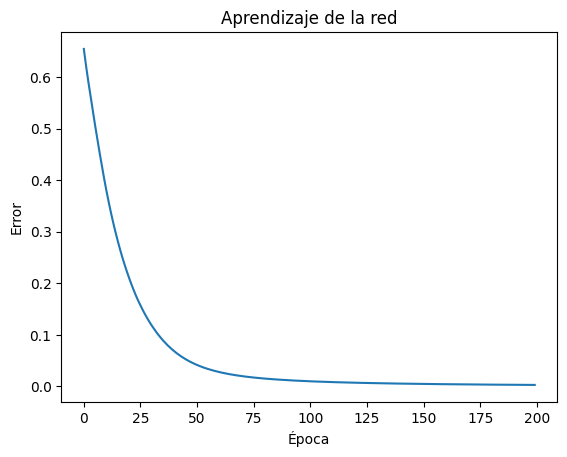

Error en prueba: 0.005953948013484478
Accuracy: 1.0


In [23]:
import matplotlib.pyplot as plt

plt.plot(historial.history["loss"])
plt.title("Aprendizaje de la red")
plt.xlabel("Época")
plt.ylabel("Error")
plt.show()

test_loss, test_accuracy = modelo.evaluate(X_test, y_test, verbose=0)
print("Error en prueba:", test_loss)
print("Accuracy:", test_accuracy)


Predecir una fruta nueva

In [24]:
fruta_nueva = np.array([[124, 19.0, 0.94]])
fruta_nueva_escalada = scaler.transform(fruta_nueva)

probabilidad = modelo.predict(fruta_nueva_escalada, verbose=0)
resultado = "BANANO" if probabilidad[0][0] >= 0.5 else "MANZANA"

print("Probabilidad:", probabilidad[0][0])
print("La red piensa que es:", resultado)


Probabilidad: 0.99858165
La red piensa que es: BANANO


# Laboratorio D: clasificación multiclase con frutas
Crear dataset multiclase

In [25]:
X_multi = np.array([
    # MANZANAS - 0
    [150,7.5,.10],[160,8.0,.15],[145,7.2,.05],[170,8.3,.20],[155,7.8,.10],
    [165,8.1,.15],[140,7.0,.05],[175,8.5,.20],[158,7.9,.10],[162,8.2,.15],
    # BANANOS - 1
    [120,18.0,.90],[125,19.0,.95],[115,17.5,.85],[130,20.0,1.00],[118,18.5,.90],
    [123,19.5,.95],[110,17.0,.80],[128,20.5,1.00],[121,18.8,.90],[126,19.2,.95],

    # NARANJAS - 2
    [180,8.0,.35],[190,8.5,.40],[175,7.8,.30],[200,9.0,.45],[185,8.2,.35],
    [195,8.7,.40],[170,7.5,.30],[205,9.2,.45],[188,8.4,.35],[192,8.6,.40]
], dtype=float)

y_multi = np.array([0]*10 + [1]*10 + [2]*10)



Separar y escalar

In [26]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

scaler_multi = StandardScaler()
X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)


Crear red con Softmax

In [27]:
tf.random.set_seed(42)

modelo_multi = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(6, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

modelo_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Entrenar, evaluar y probar una naranja nueva

In [28]:
historial_multi = modelo_multi.fit(
    X_train_multi,
    y_train_multi,
    epochs=300,
    verbose=0
)

loss_multi, accuracy_multi = modelo_multi.evaluate(
    X_test_multi,
    y_test_multi,
        verbose=0
)

probabilidades_multi = modelo_multi.predict(X_test_multi, verbose=0)
predicciones_multi = np.argmax(probabilidades_multi, axis=1)

print("Accuracy:", accuracy_multi)
print("Predicciones:", predicciones_multi)
print("Reales:", y_test_multi)

nombres_frutas = ["MANZANA", "BANANO", "NARANJA"]
fruta_nueva_multi = np.array([[190, 8.5, 0.38]])
fruta_nueva_multi = scaler_multi.transform(fruta_nueva_multi)
prob = modelo_multi.predict(fruta_nueva_multi, verbose=0)
clase = np.argmax(prob, axis=1)[0]
print("La red piensa que es:", nombres_frutas[clase])



Accuracy: 1.0
Predicciones: [2 1 2 0 1 0]
Reales: [2 1 2 0 1 0]
La red piensa que es: NARANJA


# Laboratorio E: MNIST con TensorFlow + Keras

Cargar MNIST

In [29]:
from tensorflow import keras
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) =     keras.datasets.mnist.load_data()

print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba:", x_test_mnist.shape, y_test_mnist.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28) (60000,)
Prueba: (10000, 28, 28) (10000,)


Ver una imagen y normalizar

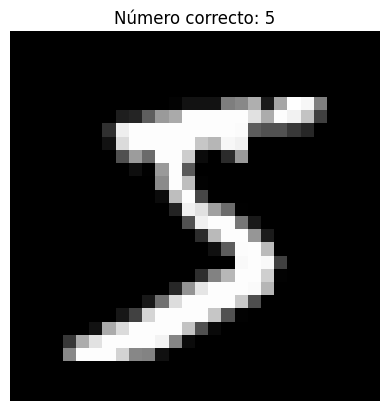

Mínimo: 0.0
Máximo: 1.0


In [30]:
import matplotlib.pyplot as plt

plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())


Crear arquitectura 784 → 128 → 10

In [31]:
import tensorflow as tf

tf.random.set_seed(42)

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo_mnist.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Compilar y entrenar

In [32]:
modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9226 - loss: 0.2693 - val_accuracy: 0.9647 - val_loss: 0.1279
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9651 - loss: 0.1183 - val_accuracy: 0.9712 - val_loss: 0.1018
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9770 - loss: 0.0794 - val_accuracy: 0.9748 - val_loss: 0.0918
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9827 - loss: 0.0590 - val_accuracy: 0.9767 - val_loss: 0.0851
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9874 - loss: 0.0444 - val_accuracy: 0.9773 - val_loss: 0.0859


Graficar loss y accuracy

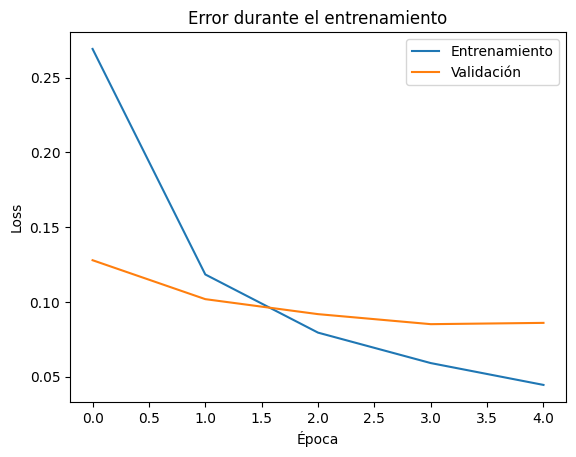

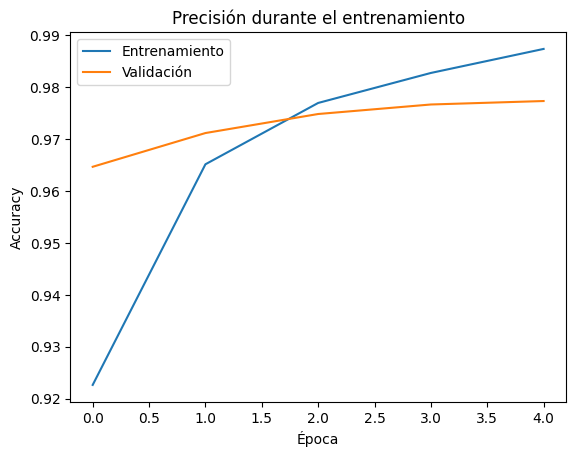

In [33]:
plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



Evaluar y predecir

In [34]:
test_loss_mnist, test_accuracy_mnist = modelo_mnist.evaluate(
    x_test_mnist,
    y_test_mnist,
    verbose=0
)

print("Error de prueba:", test_loss_mnist)
print("Accuracy de prueba:", test_accuracy_mnist)

predicciones_mnist = modelo_mnist.predict(x_test_mnist[:10], verbose=0)

for i in range(10):
    prediccion = np.argmax(predicciones_mnist[i])
    print("Imagen", i + 1, "| Real:", y_test_mnist[i], "| Predicción:", prediccion)


Error de prueba: 0.08359042555093765
Accuracy de prueba: 0.9757999777793884
Imagen 1 | Real: 7 | Predicción: 7
Imagen 2 | Real: 2 | Predicción: 2
Imagen 3 | Real: 1 | Predicción: 1
Imagen 4 | Real: 0 | Predicción: 0
Imagen 5 | Real: 4 | Predicción: 4
Imagen 6 | Real: 1 | Predicción: 1
Imagen 7 | Real: 4 | Predicción: 4
Imagen 8 | Real: 9 | Predicción: 9
Imagen 9 | Real: 5 | Predicción: 6
Imagen 10 | Real: 9 | Predicción: 9


Buscar un error del modelo

Cantidad de errores: 242


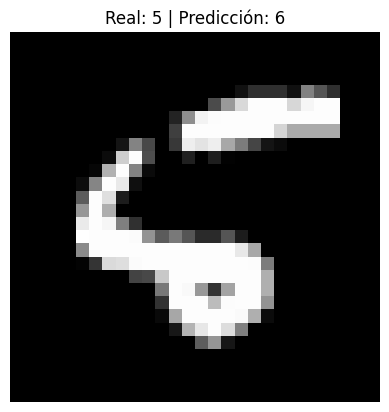

In [35]:
predicciones_todas = modelo_mnist.predict(x_test_mnist, verbose=0)
clases_predichas = np.argmax(predicciones_todas, axis=1)
errores = np.where(clases_predichas != y_test_mnist)[0]

print("Cantidad de errores:", len(errores))

indice_error = errores[0]
plt.imshow(x_test_mnist[indice_error], cmap="gray")
plt.title(
    f"Real: {y_test_mnist[indice_error]} | "
    f"Predicción: {clases_predichas[indice_error]}"
)
plt.axis("off")
plt.show()


# Laboratorio F: MNIST con PyTorch

Importar y cargar MNIST

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.76MB/s]


Crear DataLoaders

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


Definir la red

In [38]:
class RedMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.capa1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.salida = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.capa1(x)
        x = self.relu(x)
        x = self.salida(x)
        return x
modelo_pytorch = RedMNIST()
print(modelo_pytorch)


RedMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (capa1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (salida): Linear(in_features=128, out_features=10, bias=True)
)


Crear pérdida y optimizador

In [40]:
criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(
    modelo_pytorch.parameters(),
    lr=0.001
)

print("Modelo, criterio y optimizador listos")


Modelo, criterio y optimizador listos


Entrenar

In [41]:
epochs = 3

for epoch in range(epochs):
    modelo_pytorch.train()
    error_total = 0

    for imagenes, etiquetas in train_loader:
        # 1. Limpiar gradientes anteriores
        optimizador.zero_grad()

        # 2. Forward
        salidas = modelo_pytorch(imagenes)

        # 3. Loss
        error = criterio(salidas, etiquetas)

        # 4. Backpropagation
        error.backward()

        # 5. Actualizar pesos
        optimizador.step()

        error_total += error.item()

    promedio_error = error_total / len(train_loader)
    print("Época:", epoch + 1, "- Error:", round(promedio_error, 4))


Época: 1 - Error: 0.3524
Época: 2 - Error: 0.1612
Época: 3 - Error: 0.1086


Evaluar

In [42]:
modelo_pytorch.eval()
correctas = 0
total = 0

with torch.no_grad():
 for imagenes, etiquetas in test_loader:
        salidas = modelo_pytorch(imagenes)
        _, predicciones = torch.max(salidas, 1)
        total += etiquetas.size(0)
        correctas += (predicciones == etiquetas).sum().item()

accuracy_pytorch = correctas / total
print("Accuracy en prueba:", accuracy_pytorch)


Accuracy en prueba: 0.9683


Ver una predicción individual

Número real: 7
Número predicho: 7


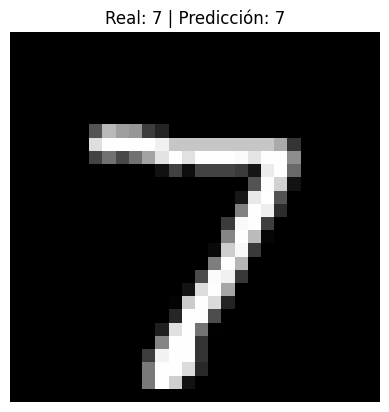

In [43]:
imagen, etiqueta_real = test_dataset[0]
entrada = imagen.unsqueeze(0)

modelo_pytorch.eval()
with torch.no_grad():
    salida = modelo_pytorch(entrada)
    prediccion = torch.argmax(salida, dim=1).item()

print("Número real:", etiqueta_real)
print("Número predicho:", prediccion)

plt.imshow(imagen.squeeze(), cmap="gray")
plt.title(f"Real: {etiqueta_real} | Predicción: {prediccion}")
plt.axis("off")
plt.show()

